In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import FuncFormatter, MaxNLocator
from matplotlib.patches import FancyArrowPatch
import seaborn as sns
import matplotlib as mpl

from scipy.stats import lognorm

sns.set_theme(style='whitegrid')

In [2]:
# Specify the parameters of the distrubtion
c               = -2.0915784326697198
alpha           = 1.0099919011379082
beta            = 1.0266672599410456
std_residuals   = 0.4220842476334173

In [3]:
# Specify the maximal acceptable error
max_acceptable_error = 0.0192 # Value found in the paper, can be changed by the user

# Case one: existing application

We will consider how to study the maximal error in the case that an Expected Threat model is already in use. To illustrate this, we will use the situation of the Expected Threat model by Karun Singh (2018) in hist blog post.<br>
In this example we have $M=192$ and $N=620,000$.

In [4]:
# Number of states/squares in the model
M = 192

# Number of training data points
N = 620_000 

<>:34: SyntaxWarning: invalid escape sequence '\w'
<>:34: SyntaxWarning: invalid escape sequence '\w'
C:\Users\kwvanarem\AppData\Local\Temp\ipykernel_31312\1337140074.py:34: SyntaxWarning: invalid escape sequence '\w'
  plt.xlabel('Estimation error ($||xT-\widehat{xT}^{(k)}||_{\infty})$')


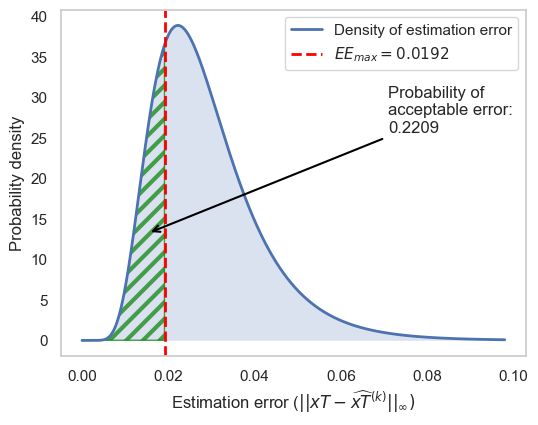

In [5]:
import matplotlib as mpl
mpl.rcParams['hatch.linewidth'] = 3.0

# Plot the distribution
plt.figure(figsize=(6, 4.5))

percentile_0999 = lognorm.ppf(0.999, s=std_residuals, scale=np.exp(c + alpha*np.log(M) - beta*np.log(np.sqrt(N))))
x = np.linspace(0, percentile_0999, 1000)
y = lognorm.pdf(x=x, s=std_residuals, scale=np.exp(c + alpha*np.log(M) - beta*np.log(np.sqrt(N))))
plt.plot(x, y, lw=2, label='Density of estimation error')

plt.fill_between(x, y, alpha=0.2)

plt.axvline(max_acceptable_error, color='red', linestyle='--', lw=2, label=rf'$EE_{{max}}={max_acceptable_error:.4f}$')
plt.fill_between(x, y, max_acceptable_error, 
                 where=(x < max_acceptable_error), 
                 alpha=0.7, 
                 facecolor='none', 
                 hatch='//',
                 edgecolor='green',            
                 )


percentile_099 = lognorm.ppf(0.99, s=std_residuals, scale=np.exp(c + alpha*np.log(M) - beta*np.log(np.sqrt(N))))
prob_acceptable_error = lognorm.cdf(max_acceptable_error, s=std_residuals, scale=np.exp(c + alpha*np.log(M) - beta*np.log(np.sqrt(N))))
x_ = min(x[np.argmax(y)], max_acceptable_error * 0.8)
y_ = lognorm.pdf(x_, s=std_residuals, scale=np.exp(c + alpha*np.log(M) - beta*np.log(np.sqrt(N))))/2
plt.annotate(f'Probability of\nacceptable error: \n{prob_acceptable_error:.4f}',
             xy=(x_, y_),
             xytext=(percentile_099, np.max(y)*0.66),
             arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
             )

plt.xlabel('Estimation error ($||xT-\widehat{xT}^{(k)}||_{\infty})$')
plt.ylabel('Probability density')
plt.legend()
plt.grid()

plt.show()

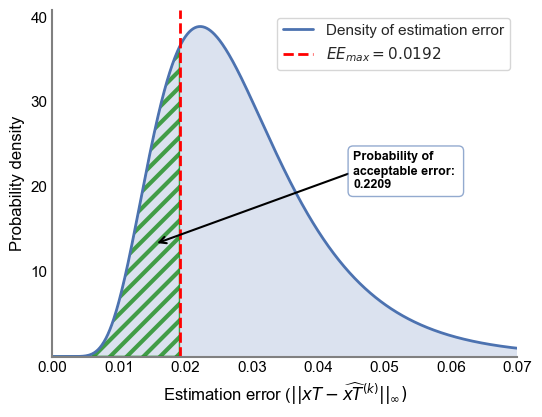

In [6]:

mpl.rcParams['hatch.linewidth'] = 3.0

line_color = sns.color_palette()[0]

# Plot the distribution
fig, ax = plt.subplots(figsize=(6, 4.5))

percentile_0999 = lognorm.ppf(
    0.999, s=std_residuals,
    scale=np.exp(c + alpha*np.log(M) - beta*np.log(np.sqrt(N)))
)

x = np.linspace(0, percentile_0999, 1000)
y = lognorm.pdf(
    x=x, s=std_residuals,
    scale=np.exp(c + alpha*np.log(M) - beta*np.log(np.sqrt(N)))
)

ax.plot(x, y, lw=2, label='Density of estimation error')
ax.fill_between(x, y, alpha=0.2)

ax.axvline(max_acceptable_error, color='red', linestyle='--', lw=2,
           label=rf'$EE_{{max}}={max_acceptable_error:.4f}$')

ax.fill_between(
    x, y, max_acceptable_error,
    where=(x < max_acceptable_error),
    alpha=0.7,
    facecolor='none',
    hatch='//',
    edgecolor='green',
)

percentile_095 = lognorm.ppf(
    0.95, s=std_residuals,
    scale=np.exp(c + alpha*np.log(M) - beta*np.log(np.sqrt(N)))
)

prob_acceptable_error = lognorm.cdf(
    max_acceptable_error, s=std_residuals,
    scale=np.exp(c + alpha*np.log(M) - beta*np.log(np.sqrt(N)))
)

x_ = min(x[np.argmax(y)], max_acceptable_error * 0.8)
y_ = lognorm.pdf(
    x_, s=std_residuals,
    scale=np.exp(c + alpha*np.log(M) - beta*np.log(np.sqrt(N))
)) / 2

# --- Arrow (clean version) ---
arrow = FancyArrowPatch(
    (percentile_095-0.0083, np.max(y)*0.50+2.2),
    (x_, y_),
    arrowstyle='->',
    mutation_scale=12,
    lw=1.5,
    color='black',
    zorder=20,
    clip_on=False
)
ax.add_patch(arrow)

# --- Annotation box ---
ax.text(
    percentile_095, np.max(y)*0.50,
    f'Probability of\nacceptable error: \n{prob_acceptable_error:.4f}',
    fontsize=9,
    color='black',
    weight='bold',
    ha='center',
    va='bottom',
    multialignment='left',
    zorder=20,
    bbox=dict(
        boxstyle='round,pad=0.4',
        facecolor='white',
        alpha=0.6,
        edgecolor=line_color,
        linewidth=1
    )
)




# Axes start at 0
ax.set_xlim(0, 0.07)
ax.set_ylim(0, None)

# Make axes (spines) grey
for spine in ['bottom', 'left']:
    ax.spines[spine].set_color('grey')
    ax.spines[spine].set_linewidth(1.5)

# Remove top/right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Ticks: remove tick lines, keep labels black
ax.tick_params(axis='both',
               which='both',
               length=0,        # removes tick lines
               colors='black')  # tick label color

# Ensure axis labels are black
ax.xaxis.label.set_color('black')
ax.yaxis.label.set_color('black')

# Remove grid
ax.grid(False)

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda y, _: '' if y == 0 else f'{y:g}')
)
ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

# Labels and legend
ax.set_xlabel('Estimation error ($||xT-\\widehat{xT}^{(k)}||_{\\infty})$')
ax.set_ylabel('Probability density')
ax.legend()

plt.show()

# Case two: Given a data set, find grid size

In [7]:
number_of_data_points = 2_480_000
desired_certainty = 0.9

# Specify the ratio between the number of discretization points in the x and y directions
nx_ny_ratio = 3/4

# Specify the minimal number of descretization points in the x-direction
min_nx = 6 # Corresponds to (6x5) grid
max_nx = 32 # Corresponds to (32x24) grid


In [8]:
nxs = np.arange(min_nx, max_nx+1)
nys = np.ceil(nx_ny_ratio*nxs).astype(int)

print([(int(nxs[i]), int(nys[i])) for i in range(len(nxs))])

Ms = nxs * nys

Ms = Ms[Ms < 500]

[(6, 5), (7, 6), (8, 6), (9, 7), (10, 8), (11, 9), (12, 9), (13, 10), (14, 11), (15, 12), (16, 12), (17, 13), (18, 14), (19, 15), (20, 15), (21, 16), (22, 17), (23, 18), (24, 18), (25, 19), (26, 20), (27, 21), (28, 21), (29, 22), (30, 23), (31, 24), (32, 24)]


In [9]:
sns.set_theme(style='whitegrid')

Max M with acceptable error: 80
Corresponding nx: 10
Corresponding ny: 8


<>:40: SyntaxWarning: invalid escape sequence '\m'
<>:40: SyntaxWarning: invalid escape sequence '\ '
<>:40: SyntaxWarning: invalid escape sequence '\m'
<>:40: SyntaxWarning: invalid escape sequence '\m'
<>:76: SyntaxWarning: invalid escape sequence '\w'
<>:40: SyntaxWarning: invalid escape sequence '\m'
<>:40: SyntaxWarning: invalid escape sequence '\ '
<>:40: SyntaxWarning: invalid escape sequence '\m'
<>:40: SyntaxWarning: invalid escape sequence '\m'
<>:76: SyntaxWarning: invalid escape sequence '\w'
C:\Users\kwvanarem\AppData\Local\Temp\ipykernel_31312\1506466227.py:40: SyntaxWarning: invalid escape sequence '\m'
  f'$\mathbf{{M\ ={int(M)}}}$\n$\mathbf{{n_x={int(n_x)}}}$\n$\mathbf{{n_y={int(n_y)}}}$',
C:\Users\kwvanarem\AppData\Local\Temp\ipykernel_31312\1506466227.py:40: SyntaxWarning: invalid escape sequence '\ '
  f'$\mathbf{{M\ ={int(M)}}}$\n$\mathbf{{n_x={int(n_x)}}}$\n$\mathbf{{n_y={int(n_y)}}}$',
C:\Users\kwvanarem\AppData\Local\Temp\ipykernel_31312\1506466227.py:40: Syntax

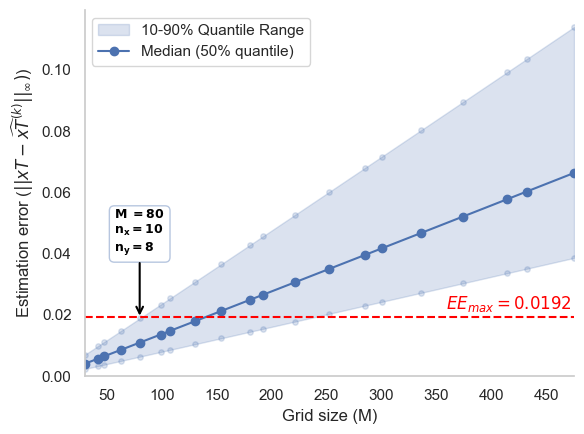

In [10]:
fig, axes = plt.subplots(figsize=(6, 4.5))


sns_palette = sns.color_palette()
line_color = sns_palette[0]
fill_color = sns_palette[0]

# Define the quantiles
quantiles = [0.1, 0.25, 0.5, 0.75, 0.9]
if not desired_certainty in quantiles:
    quantiles.append(desired_certainty)
quantiles.sort(reverse=True)

qs_010 = lognorm.ppf(0.1, s=std_residuals, scale=np.exp(c + alpha*np.log(Ms) - beta*np.log(np.sqrt(N))))
qs_090 = lognorm.ppf(0.9, s=std_residuals, scale=np.exp(c + alpha*np.log(Ms) - beta*np.log(np.sqrt(N))))
axes.fill_between(Ms, qs_010, qs_090, alpha=0.2, color=fill_color, label='10-90% Quantile Range')

qs_median = lognorm.ppf(0.5, s=std_residuals, scale=np.exp(c + alpha*np.log(Ms) - beta*np.log(np.sqrt(N))))
axes.plot(Ms, qs_median, label='Median (50% quantile)', color=line_color, marker='o')

axes.scatter(Ms, qs_090, color=fill_color, marker='o', s=15, alpha=0.2)
axes.scatter(Ms, qs_010, color=fill_color, marker='o', s=15, alpha=0.2)

qs = lognorm.ppf(desired_certainty, s=std_residuals, scale=np.exp(c + alpha*np.log(Ms) - beta*np.log(np.sqrt(N))))

# Get the index of the largest M below max_max_error
index = np.argwhere(qs < max_acceptable_error)[-1][0]
# Get the corresponding M, nx, and ny values
M = Ms[index]
n_x = nxs[index]
n_y = nys[index]
print(f"Max M with acceptable error: {M}")
print(f"Corresponding nx: {n_x}")
print(f"Corresponding ny: {n_y}")

# Text
axes.text(
    M,
    qs[index] + 0.02,
    f'$\mathbf{{M\ ={int(M)}}}$\n$\mathbf{{n_x={int(n_x)}}}$\n$\mathbf{{n_y={int(n_y)}}}$',
    fontsize=9,
    color='black',
    weight='bold',
    ha='center',
    va='bottom',
    multialignment='left',
    zorder=20,
    bbox=dict(
        boxstyle='round,pad=0.4',
        facecolor='white',
        alpha=0.4,
        edgecolor=line_color,
        linewidth=1
    )
)

arrow = FancyArrowPatch(
    (M, qs[index] + 0.019),
    (M, qs[index]),
    arrowstyle='->',
    mutation_scale=12,
    lw=1.5,
    color='black',
    zorder=20,
    clip_on=False
)

axes.add_patch(arrow)


# Add horizontal line at max_max_error
# axes.axhline(y=max_acceptable_error, color='red', linestyle='--', label=rf'$ME_{{max}}$ ({max_acceptable_error:.4f})')
axes.axhline(y=max_acceptable_error, color='red', linestyle='--')
axes.text(axes.get_xlim()[1]*0.95, max_acceptable_error*1.05, rf'$EE_{{max}}={max_acceptable_error:.4f}$', color='red', fontsize=12, ha='right', va='bottom')
axes.set_xlabel('Grid size (M)')
axes.set_ylabel('Estimation error ($||xT-\widehat{xT}^{(k)}||_{\infty})$)')
# axes.set_title('Quantiles of xT_error_inf_norm vs M')
axes.spines[['top', 'right']].set_visible(False)
plt.legend()
axes.grid(False)
plt.tight_layout()
axes.set_axisbelow(True)
axes.set_xlim(Ms.min(), Ms.max())
axes.set_ylim(0, None)

plt.show()


# Case three: Given a grid size, find data set size

In [11]:
# Specify desired grid
n_x = 16 # 24
n_y = 12 # 18

M = n_x * n_y
print(f"Grid size (M): {M}")

Ns = np.linspace(100_000, 10_000_000, 9000, endpoint=False)
Ns = np.arange(100_000, 10_000_000, 1_000)

Grid size (M): 192


Min N with acceptable error: 3348000


<>:59: SyntaxWarning: invalid escape sequence '\m'
<>:59: SyntaxWarning: invalid escape sequence '\m'
C:\Users\kwvanarem\AppData\Local\Temp\ipykernel_31312\1533441905.py:59: SyntaxWarning: invalid escape sequence '\m'
  f'$\mathbf{{N={int(N):,}}}$',


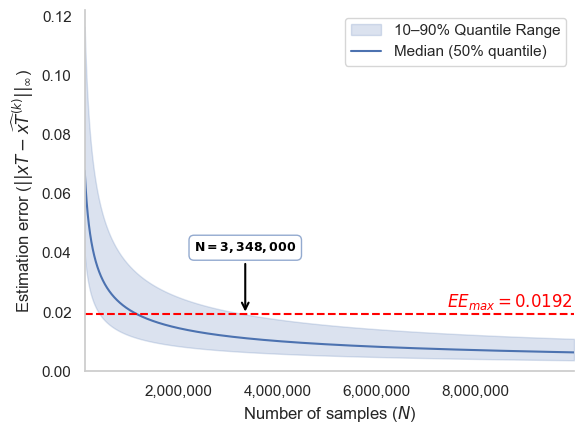

In [12]:
fig, axes = plt.subplots(figsize=(6, 4.5))

sns_palette = sns.color_palette()
line_color = sns_palette[0]
fill_color = sns_palette[0]

# Define quantiles
quantiles = [0.1, 0.25, 0.5, 0.75, 0.9]
if desired_certainty not in quantiles:
    quantiles.append(desired_certainty)
quantiles.sort(reverse=True)

# --- Quantile band (10–90%) ---
qs_010 = lognorm.ppf(
    0.1,
    s=std_residuals,
    scale=np.exp(c + alpha*np.log(M) - beta*np.log(np.sqrt(Ns))))
qs_090 = lognorm.ppf(
    0.9,
    s=std_residuals,
    scale=np.exp(c + alpha*np.log(M) - beta*np.log(np.sqrt(Ns))))

axes.fill_between(
    Ns, qs_010, qs_090,
    alpha=0.2,
    color=fill_color,
    label='10–90% Quantile Range'
)

# --- Median line ---
qs_median = lognorm.ppf(
    0.5,
    s=std_residuals,
    scale=np.exp(c + alpha*np.log(M) - beta*np.log(np.sqrt(Ns))))

axes.plot(
    Ns,
    qs_median,
    color=line_color,
    # marker='o',
    label='Median (50% quantile)'
)

# --- Target quantile ---
qs = lognorm.ppf(
    desired_certainty,
    s=std_residuals,
    scale=np.exp(c + alpha*np.log(M) - beta*np.log(np.sqrt(Ns)))
)

index = np.argwhere(qs < max_acceptable_error)[0][0]
N = Ns[index]
print(f"Min N with acceptable error: {N}")

# --- Annotation box ---
axes.text(
    N,
    qs[index] + 0.02,
    f'$\mathbf{{N={int(N):,}}}$',
    fontsize=9,
    color='black',
    weight='bold',
    ha='center',
    va='bottom',
    multialignment='left',
    zorder=20,
    bbox=dict(
        boxstyle='round,pad=0.4',
        facecolor='white',
        alpha=0.6,
        edgecolor=line_color,
        linewidth=1
    )
)

# --- Arrow (clean version) ---
arrow = FancyArrowPatch(
    (N, qs[index] + 0.018),
    (N, qs[index]),
    arrowstyle='->',
    mutation_scale=12,
    lw=1.5,
    color='black',
    zorder=20,
    clip_on=False
)
axes.add_patch(arrow)

# --- Horizontal threshold line ---
axes.axhline(
    y=max_acceptable_error,
    color='red',
    linestyle='--'
)

axes.text(
    axes.get_xlim()[1]*0.95,
    max_acceptable_error*1.05,
    rf'$EE_{{max}}={max_acceptable_error:.4f}$',
    color='red',
    fontsize=12,
    ha='right',
    va='bottom'
)

# --- Labels ---
axes.set_xlabel(r'Number of samples ($N$)')
axes.set_ylabel(r'Estimation error ($||xT-\widehat{xT}^{(k)}||_{\infty}$)')

# --- Style cleanup (match new plot style) ---
axes.spines[['top', 'right']].set_visible(False)
axes.grid(False)
axes.set_axisbelow(True)

axes.set_xlim(Ns.min(), Ns.max())
axes.set_ylim(0, None)
axes.xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'{int(x):,}' if x >= 1e6 else f'{x:.0f}')
)

plt.legend()
plt.tight_layout()
plt.show()

In [13]:
N

np.int64(3348000)

In [14]:
print(f"This corresponds to {N/620_000:.3f} seasons of data.")

This corresponds to 5.400 seasons of data.


# Expected Threat models for the three cases

In [15]:
import sys
import pandas as pd

sys.path.append("../../")
from xThreat import xThreat

sns.reset_defaults()

In [16]:
data_path = '../../1-data-preparation/data-storage/preprocessed_data_top5_leagues.parquet'
df_events = pd.read_parquet(data_path, engine='fastparquet')
df_events['shot'] = ~df_events['shot_outcome'].isna()
df_events['goal'] = df_events['shot_outcome'] == 'Goal'
df_events.drop(columns=['id', 'shot_outcome', 'possession'], inplace=True)
df_size_bytes = df_events.memory_usage(deep=True).sum()
df_size_mb = df_size_bytes / (1024 ** 2)  # Convert to MB

print(f"DataFrame size: {df_size_mb:.2f} MB")

DataFrame size: 1287.32 MB


# Existing model: Singh (2018)

In [17]:
# Values from blog post at https://karun.in/blog/expected-threat.html
xT_values_singh2018 = np.array([
    [0.003, 0.003, 0.003, 0.004, 0.005, 0.004, 0.004, 0.005, 0.004, 0.003, 0.003, 0.002],
    [0.004, 0.005, 0.003, 0.004, 0.005, 0.005, 0.005, 0.006, 0.005, 0.004, 0.003, 0.003],
    [0.003, 0.004, 0.003, 0.004, 0.006, 0.007, 0.007, 0.007, 0.005, 0.004, 0.004, 0.004],
    [0.004, 0.004, 0.004, 0.004, 0.004, 0.004, 0.005, 0.005, 0.004, 0.004, 0.004, 0.004],
    [0.004, 0.004, 0.004, 0.004, 0.004, 0.004, 0.005, 0.005, 0.004, 0.005, 0.005, 0.005],
    [0.005, 0.005, 0.006, 0.006, 0.006, 0.006, 0.005, 0.006, 0.006, 0.006, 0.006, 0.006],
    [0.007, 0.007, 0.007, 0.007, 0.007, 0.008, 0.008, 0.008, 0.008, 0.008, 0.008, 0.007],
    [0.008, 0.008, 0.009, 0.009, 0.010, 0.009, 0.010, 0.009, 0.009, 0.010, 0.010, 0.008],
    [0.010, 0.011, 0.012, 0.012, 0.013, 0.013, 0.012, 0.014, 0.013, 0.013, 0.012, 0.011],
    [0.013, 0.015, 0.016, 0.016, 0.017, 0.017, 0.019, 0.018, 0.017, 0.016, 0.015, 0.014],
    [0.018, 0.020, 0.022, 0.023, 0.025, 0.025, 0.025, 0.024, 0.024, 0.024, 0.022, 0.019],
    [0.025, 0.029, 0.034, 0.034, 0.033, 0.033, 0.035, 0.037, 0.036, 0.036, 0.031, 0.026],
    [0.037, 0.042, 0.046, 0.044, 0.048, 0.052, 0.042, 0.046, 0.047, 0.049, 0.044, 0.039],
    [0.048, 0.056, 0.067, 0.068, 0.068, 0.089, 0.116, 0.077, 0.065, 0.068, 0.060, 0.051],
    [0.060, 0.075, 0.094, 0.089, 0.126, 0.171, 0.176, 0.124, 0.096, 0.096, 0.077, 0.063],
    [0.066, 0.092, 0.103, 0.123, 0.158, 0.413, 0.371, 0.158, 0.126, 0.136, 0.094, 0.068],
])

In [18]:
# Create xThreat instance and assign xT values
# Note not all functions will work since the values are not actually calculated but assigned from the paper
xT_singh2018 = xThreat(n_x=16, n_y=12)
xT_singh2018.xT = np.flipud(np.transpose(xT_values_singh2018)).flatten()

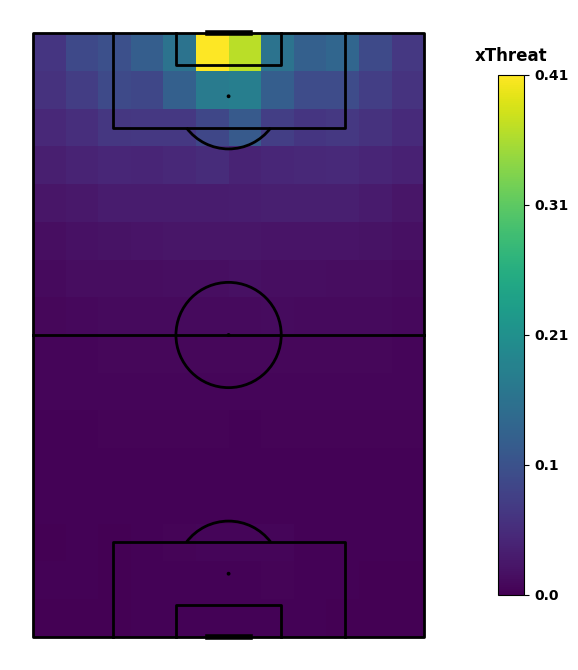

In [19]:
xT_singh2018.plot_xThreat(cmap='viridis')

## For finding the grid for the data set size

In [20]:
df_N_2_480_000 = df_events.head(2_480_000).copy()
xT_10x8_N_2_480_000 = xThreat(n_x=10, n_y=8)
xT_10x8_N_2_480_000.fit(df_N_2_480_000)

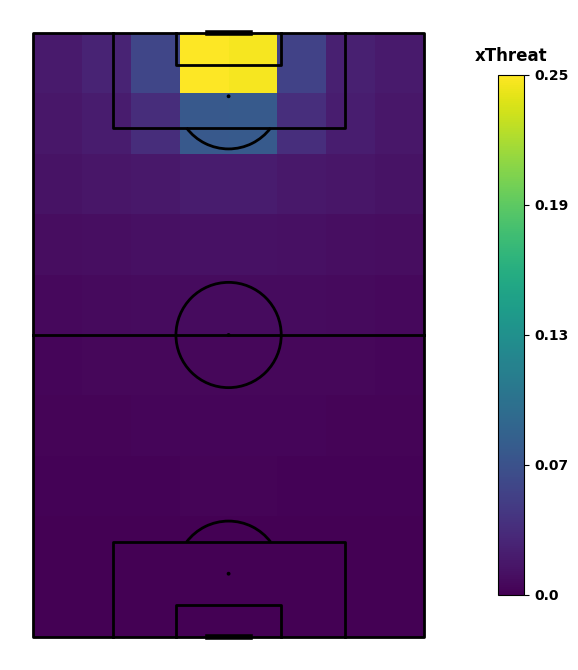

In [21]:
xT_10x8_N_2_480_000.plot_xThreat(cmap='viridis')

## For finding the data set size for grid size

In [22]:
df_N_3_350_000 = df_events.head(3_350_000).copy()
xT_16x12_N_3_350_000 = xThreat(n_x=16, n_y=12)
xT_16x12_N_3_350_000.fit(df_N_3_350_000)

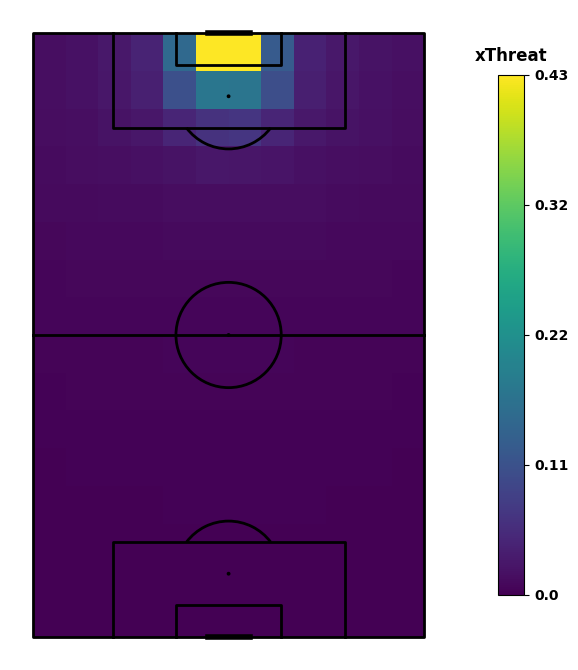

In [23]:
xT_16x12_N_3_350_000.plot_xThreat(cmap='viridis')

In [24]:
xT_16x12_N_3_350_000.save_to_pickle('xT_16x12_N_3_350_000.pkl')